# MCE 531 â€” YOLOv9 Tomato Leaf Disease Detection

This notebook evaluates YOLOv9c for seven-class tomato leaf disease detection using transfer learning. Five initial learning rates are compared while keeping the remaining training settings fixed.

**Best reported configuration:** `lr0 = 0.001`, with validation `mAP@0.5 = 0.7674` and `mAP@0.5:0.95 = 0.5145`.

> This project was originally developed in Google Colab. Set `PROJECT_ROOT` below to your own local/Colab project directory before running.


In [ ]:
import os
from pathlib import Path

# Set MCE531_PROJECT_ROOT only if the notebook is not run from the cloned repo.
default_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROJECT_ROOT = Path(os.getenv('MCE531_PROJECT_ROOT', default_root)).resolve()
DATASET_DIR = PROJECT_ROOT / 'dataset'
RUNS_DIR = PROJECT_ROOT / 'Tomato_Disease_Detection'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')


In [ ]:
# Navigating to the project folder
%cd {PROJECT_ROOT}

# Unzip the dataset into a folder named 'dataset'
!unzip -q archive.zip -d dataset

print("Dataset extracted successfully!")

/content/drive/MyDrive/MCE531_Project
replace dataset/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace dataset/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset extracted successfully!


In [ ]:
!ls {DATASET_DIR}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# The 5 mandatory initial learning rates
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]

for lr in learning_rates:
    print(f"\n--- Starting YOLOv9 Training | Initial LR: {lr} ---\n")

    try:
        # Initialize the standard YOLOv9 model with COCO pre-trained weights
        model = YOLO('yolov9c.pt')

        # Training using the exact constraints from the project brief
        results = model.train(
            data=str(DATASET_DIR / 'data.yaml'),
            epochs=100,             # Fixed value
            batch=16,               # Fixed value
            imgsz=640,              # Maintain consistency across groups
            optimizer='AdamW',      # Assigned optimizer for v5-11
            lr0=lr,                 # Current learning rate in the loop
            pretrained=True,        # Mandatory transfer learning

            # Authorized augmentations
            mosaic=1.0,
            mixup=0.2,
            cutmix=0.2,

            # Disable YOLO's default augmentations to comply with the project brief
            degrees=0.0,
            translate=0.0,
            scale=0.0,
            shear=0.0,
            perspective=0.0,
            fliplr=0.0,
            flipud=0.0,
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.0,

            project=str(RUNS_DIR),
            name=f'yolov9_run_lr_{lr}'
        )

    except RuntimeError as e:
        # This catches the "Loss NaN/Inf detected" error
        print(f"\n[ERROR] Training crashed for LR {lr}. This is expected for high learning rates with AdamW.")
        print(f"Error details: {e}")
        print("Safely skipping to the next learning rate...\n")


--- Starting YOLOv9 Training | Initial LR: 0.1 ---

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.2, data=/content/drive/MyDrive/MCE531_Project/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.1, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9_run_lr_0.1, nbs=64, nms=False,

In [ ]:
from ultralytics import YOLO

# 1. Load the interrupted model's last saved weights
model = YOLO(str(RUNS_DIR / 'yolov9_run_lr_1e-05' / 'weights' / 'last.pt'))

# 2. Resume training to finish the remaining epochs
model.train(resume=True)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.2, data=/content/drive/MyDrive/MCE531_Project/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/MCE531_Project/Tomato_Disease_Detection/yolov9_run_lr_1e-05/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78a274c20fe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

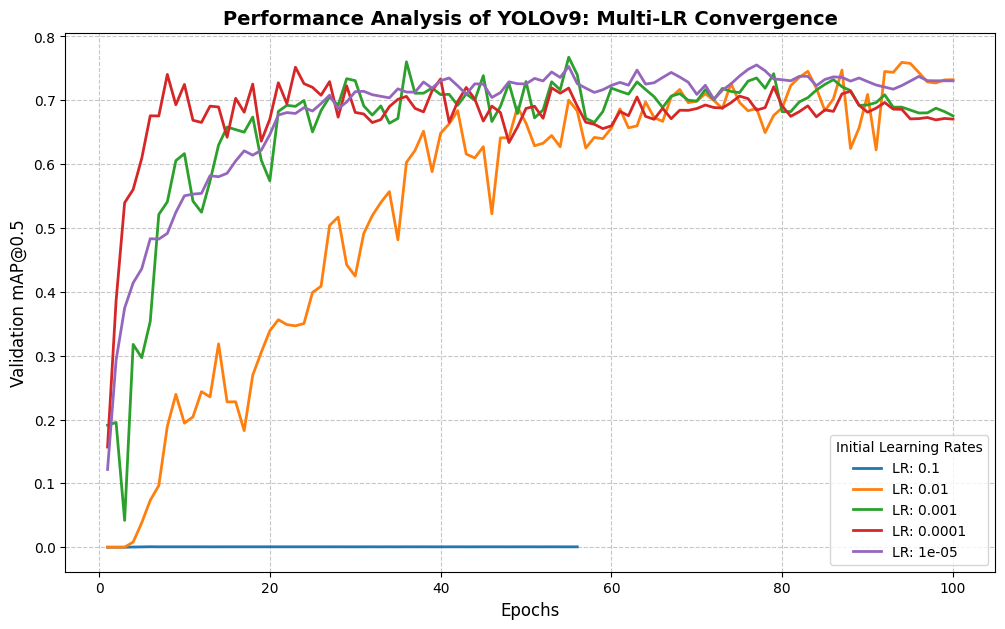

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Your 5 assigned learning rates
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]
base_path = str(RUNS_DIR)

# Set up the visual style of the graph
plt.figure(figsize=(12, 7))

for lr in learning_rates:
    csv_file = f'{base_path}/yolov9_run_lr_{lr}/results.csv'

    # Check whether results are available for this learning rate
    if os.path.exists(csv_file):
        # Read the CSV file
        df = pd.read_csv(csv_file)

        #stripping column names
        df.columns = df.columns.str.strip()

        # Plot the Validation mAP@0.5 against the Epochs
        if 'metrics/mAP50(B)' in df.columns:
            plt.plot(df['epoch'], df['metrics/mAP50(B)'], linewidth=2, label=f'LR: {lr}')
    else:
        print(f"Note: No results found for LR {lr}.")

# Formatting of  the graph
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation mAP@0.5', fontsize=12)
plt.title('Performance Analysis of YOLOv9: Multi-LR Convergence', fontsize=14, fontweight='bold')
plt.legend(title="Initial Learning Rates")
plt.grid(True, linestyle='--', alpha=0.7)

# Save a high-quality image of the graph directly to your Colab environment
plt.savefig(RESULTS_DIR / 'Figure_2_Multi_LR_Convergence.png', dpi=300, bbox_inches='tight')

# Display the graph on your screen
plt.show()

In [ ]:
import pandas as pd
import os

# The 5 assigned learning rates
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]
base_path = str(RUNS_DIR)

# Create an empty list to store our table data
table2_data = []

for lr in learning_rates:
    csv_file = f'{base_path}/yolov9_run_lr_{lr}/results.csv'

    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file)

        # Clean up column names
        df.columns = df.columns.str.strip()

        # Find the row (epoch) with the absolute highest mAP@0.5
        best_epoch_idx = df['metrics/mAP50(B)'].idxmax()
        best_metrics = df.iloc[best_epoch_idx]

        # Store the required metrics
        table2_data.append({
            'LR': lr,
            'mAP@0.5': round(best_metrics['metrics/mAP50(B)'], 4),
            'mAP@0.5:0.95': round(best_metrics['metrics/mAP50-95(B)'], 4),
            'Precision': round(best_metrics['metrics/precision(B)'], 4),
            'Recall': round(best_metrics['metrics/recall(B)'], 4)
        })
    else:
        # Handle the 0.1 learning rate that crashed
        table2_data.append({'LR': lr, 'mAP@0.5': 'Exploded', 'mAP@0.5:0.95': '-', 'Precision': '-', 'Recall': '-'})

# Display as a clean table
table2_df = pd.DataFrame(table2_data)
print("--- Table 2: Optimal Learning Rate Selection ---")
print(table2_df.to_string(index=False))

--- Table 2: Optimal Learning Rate Selection ---
     LR  mAP@0.5  mAP@0.5:0.95  Precision  Recall
0.10000   0.0008        0.0002     0.0006  0.1377
0.01000   0.7593        0.4907     0.8228  0.6318
0.00100   0.7674        0.5145     0.6994  0.7812
0.00010   0.7518        0.4887     0.8227  0.6788
0.00001   0.7553        0.4992     0.7911  0.6768


In [ ]:
from ultralytics import YOLO

#best learning rate from Table 2
best_lr = 0.001

# Point directly to the 'best.pt' weights of the winning model
best_weight_path = str(RUNS_DIR / f'yolov9_run_lr_{best_lr}' / 'weights' / 'best.pt')

print(f"\n--- Extracting Per-Class Metrics using Best LR ({best_lr}) ---")
model = YOLO(best_weight_path)

# Run the validation tool to calculate per-class stats
metrics = model.val(data=str(DATASET_DIR / 'data.yaml'), split='val')


--- Extracting Per-Class Metrics using Best LR (0.001) ---
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9c summary (fused): 156 layers, 25,324,645 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 29.0±3.1 MB/s, size: 33.7 KB)
val: Scanning /content/drive/MyDrive/MCE531_Project/dataset/valid/labels.cache... 61 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 17.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.4s
                   all         61        196      0.703       0.78      0.768      0.515
        Bacterial Spot          3          4       0.57      0.676      0.653      0.392
          Early_Blight         31         96      0.737      0.885      0.826      0.484
               Healthy         19         19      0.935          1      0.995      0.944
           Late_blight         13         29      0.

Running inference and building the grid...

Done! The grid is saved to your Drive at: /content/drive/MyDrive/MCE531_Project/Figure_3_Qualitative_Results_Grid.png


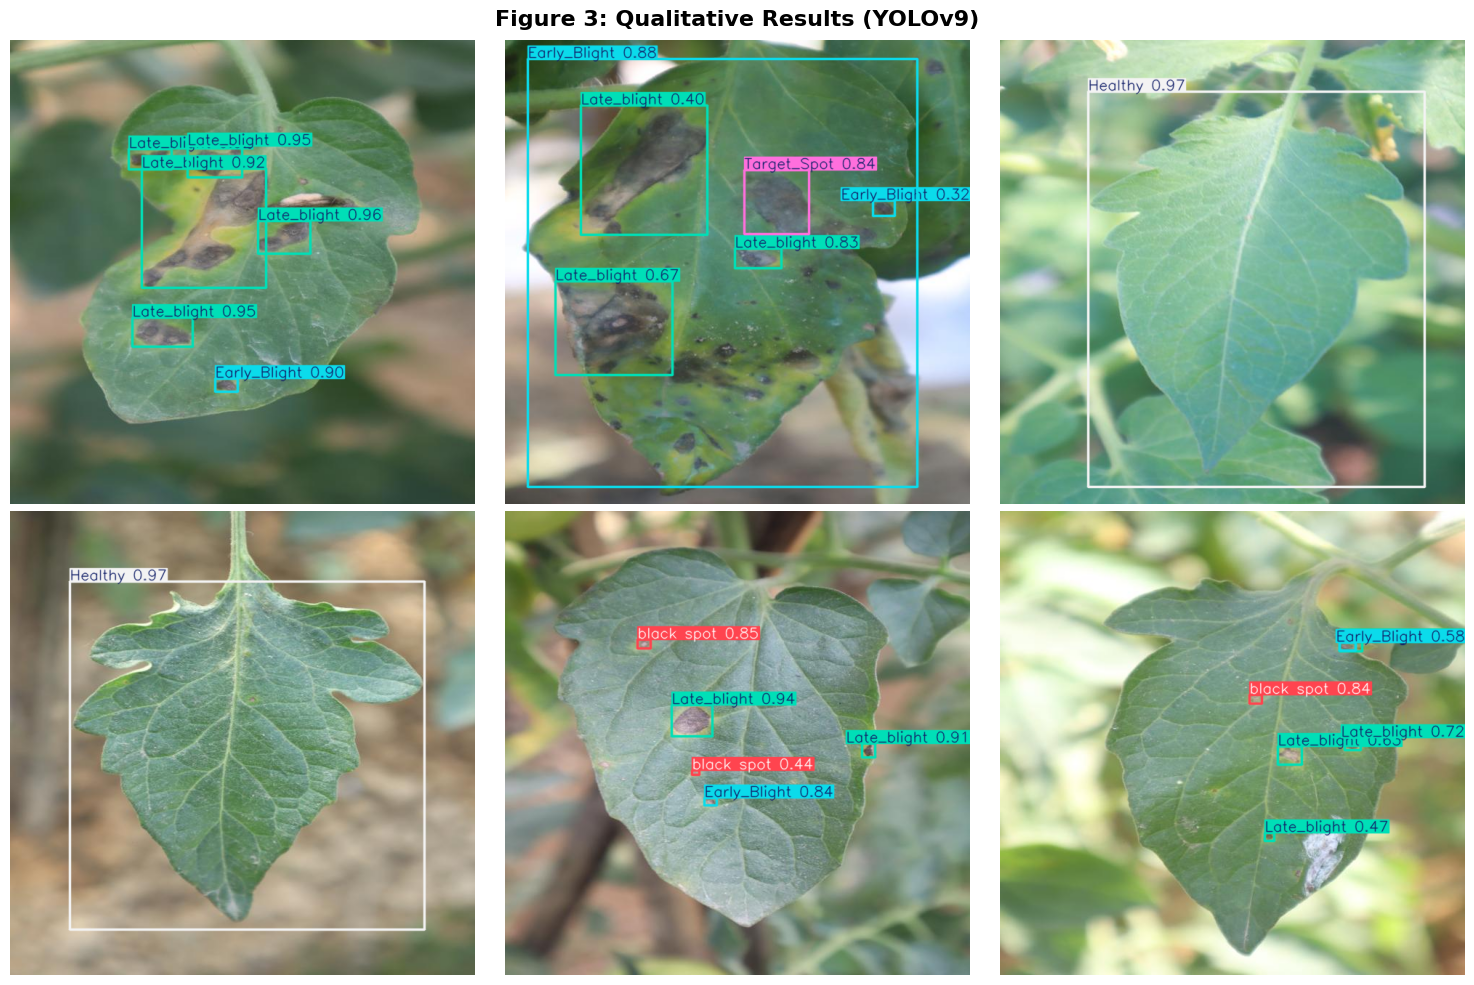

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Best learning rate
best_lr = 0.001
best_weight_path = str(RUNS_DIR / f'yolov9_run_lr_{best_lr}' / 'weights' / 'best.pt')

# Load your winning YOLOv9 model
model = YOLO(best_weight_path)

# 2. Get exactly 6 random validation images
val_images_path = str(DATASET_DIR / 'valid' / 'images')
all_val_images = [os.path.join(val_images_path, img) for img in os.listdir(val_images_path) if img.endswith('.jpg')]
sample_images = random.sample(all_val_images, 6)

# 3. Set up a 2x3 grid figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Figure 3: Qualitative Results (YOLOv9)', fontsize=16, fontweight='bold')
axes = axes.flatten()

print("Running inference and building the grid...")

# Loop through the 6 images, run prediction, and plot them in the grid
for i, img_path in enumerate(sample_images):
    # Run inference silently
    results = model.predict(source=img_path, conf=0.25, verbose=False)

    # Extract the image with the bounding boxes drawn on it
    annotated_img = results[0].plot()

    # Convert from OpenCV's BGR format to Matplotlib's RGB format
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Place the image in the current grid slot
    axes[i].imshow(annotated_img_rgb)
    axes[i].axis('off')

plt.tight_layout()

# 4. Save the final grid as a single high-quality image
save_path = str(RESULTS_DIR / 'Figure_3_Qualitative_Results_Grid.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"\nDone! The grid is saved to your Drive at: {save_path}")
plt.show() # Display the grid on your screen